# Notebook 19 - Avances y próximos pasos — tras la sesión del 9 de julio

Pieza central: un ejemplo de **separación** donde la estrategia dinámica
aumentada supera, en forma cerrada, al mejor esquema estático. Tres regímenes
aparecen todo el tiempo; conviene fijar los nombres desde ya:

- **estático**: el plan se fija de antemano, nada se adapta;
- **dinámico binario**: adaptativo, pero la prueba solo dice 0 vs ≥1;
- **dinámico aumentado**: adaptativo y la prueba devuelve el conteo exacto.

Alrededor: el algoritmo eficiente en regímenes tratables, el modelo de ruido y
la anatomía del hueco del greedy. Cada número se regenera aquí.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

# --- el ejemplo de separación, en dos funciones ---
def util_estatico(B, q):
    '''Óptimo estático (individual) sobre u: B*q.'''
    return B * q

def util_dinamico(B, G, q):
    '''Cota inferior del dinámico aumentado sobre u: 1-(1-q)^(kG),
    con kG=(B-log2 G)*G. Devuelve (valor, kG) o (None, None) si B<1+log2 G.'''
    logG = math.log2(G)
    if abs(logG - round(logG)) > 1e-9:
        raise ValueError('G debe ser potencia de 2')
    logG = round(logG)
    k = B - logG
    if k < 1:
        return None, None
    kG = k * G
    return 1.0 - (1.0 - q) ** kG, kG

print('funciones listas')

funciones listas


## 1. El ejemplo de separación

**El montaje.** Imagínense una población infinita y toda idéntica: cada persona
con utilidad u y probabilidad q de estar sana, con q<0.5. Las pruebas grupales
son de tamaño G y el budget es B = k + log2(G). Se acredita u a quien queda en
un pool con conteo cero. La pregunta ancla: ¿cuándo el **dinámico aumentado**
le gana al mejor **estático**? (Supuestos: estados i.i.d., G potencia de 2,
utilidad aditiva, crédito una vez por persona.)

**Óptimo estático.** La métrica es utilidad por prueba. Una prueba individual
rinde $u\,q$; una de grupo $g$ rinde $u\,g\,q^g\le u\,q$ para $q<1/2$. Individual
domina:  $U^{\text{est}} = B\,u\,q$.

**Dinámico aumentado.** Con $B=k+\log_2 G$ se prueban $k$ grupos disjuntos de
$G$; si un grupo tiene algún sano (conteo menor que el tamaño), una búsqueda
binaria de conteo lo aísla en $\log_2 G$ pruebas. Garantiza acreditar al menos
un sano cuando lo hay entre las $kG$ personas:

$$U^{\text{din}} \ge u\,\bigl(1-(1-q)^{kG}\bigr), \qquad kG=(B-\log_2 G)\,G.$$

In [2]:
# instancia ancla: prevalencia alta (q=0.1), grupos de 16, presupuesto 6
q, G, B = 0.1, 16, 6
est = util_estatico(B, q)
din, kG = util_dinamico(B, G, q)
print(f'q={q}  G={G}  B={B}  (k={B-round(math.log2(G))}, cubre kG={kG} personas)')
print(f'  estático  U/u = B*q          = {est:.3f}')
print(f'  din. aumentado  U/u = 1-(1-q)^kG   = {din:.3f}')
print(f'  ventaja del aumentado: {din-est:+.3f}u  ({100*(din/est-1):+.0f}%)')

q=0.1  G=16  B=6  (k=2, cubre kG=32 personas)
  estático  U/u = B*q          = 0.600
  din. aumentado  U/u = 1-(1-q)^kG   = 0.966
  ventaja del aumentado: +0.366u  (+61%)


**Un cambiecito que refuerza el ejemplo.** El mensaje original aproximaba
la cobertura como $kG \sim B$; contando con cuidado, las $k = B-\log_2 G$
pruebas frescas cubren $kG = (B-\log_2 G)\,G$ personas — que es $\Theta(B\,G)$
para $B\gg\log_2 G$ (en el ejemplo ancla, 32 exacto, no 96). El factor $G$ no es
cosmético: por Bernoulli $1-(1-q)^{B}\le B\,q$ siempre, así que con cobertura
$\sim B$ el aumentado no ganaría nunca. Con la cobertura real gana con holgura —
abajo, los dos exponentes sobre el ejemplo ancla.

In [3]:
# los dos exponentes sobre el ejemplo ancla (q=0.1, G=16, B=6)
con_B = 1 - (1 - q) ** B          # cobertura ~B (la aproximación del mensaje)
# autoverificación (Bernoulli): con cobertura ~B nunca se le gana al estático
assert all(1 - (1 - qq) ** b <= b * qq + 1e-12
           for qq in np.linspace(0.02, 0.48, 25) for b in range(2, 15))
print(f'estático exacto          B·q = {est:.3f}')
print(f'aumentado, exponente ~B ({B:>2}): {con_B:.3f}   pierde siempre (Bernoulli)')
print(f'aumentado, exponente kG ({kG}): {din:.3f}   gana con holgura')

estático exacto          B·q = 0.600
aumentado, exponente ~B ( 6): 0.469   pierde siempre (Bernoulli)
aumentado, exponente kG (32): 0.966   gana con holgura


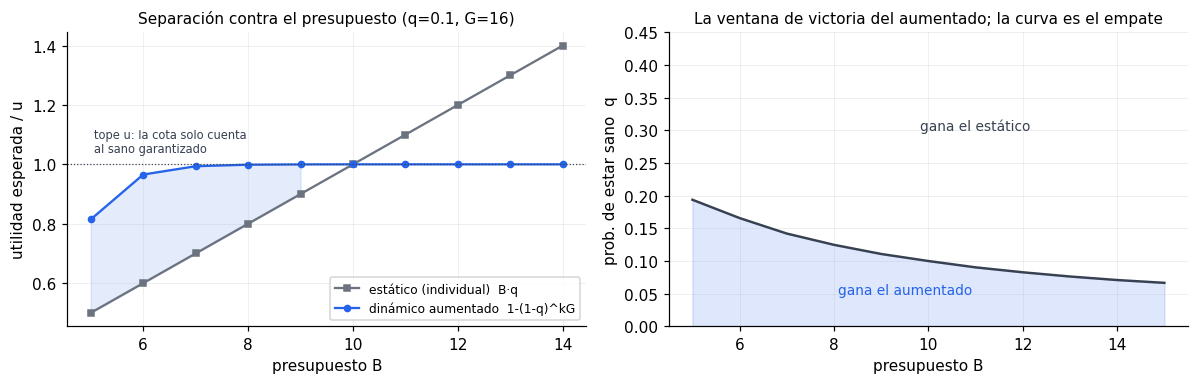

In [4]:
# figura: estático vs dinámico aumentado contra el presupuesto B (q=0.1, G=16)
q, G = 0.1, 16
Bs = list(range(1 + round(math.log2(G)), 15))
est = [util_estatico(b, q) for b in Bs]
din = [util_dinamico(b, G, q)[0] for b in Bs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

ax1.plot(Bs, est, marker='s', ms=4, color=GRIS, label='estático (individual)  B·q')
ax1.plot(Bs, din, marker='o', ms=4, color=AZUL, label='dinámico aumentado  1-(1-q)^kG')
ax1.fill_between(Bs, est, din, where=[d > e for e, d in zip(est, din)],
                 color=AZUL, alpha=0.12)
ax1.axhline(1.0, color=TINTA, ls=':', lw=0.8)
ax1.annotate('tope u: la cota solo cuenta\nal sano garantizado',
             (Bs[0], 1.0), textcoords='offset points', xytext=(2, 6),
             ha='left', va='bottom', fontsize=7.5, color=TINTA)
ax1.set_xlabel('presupuesto B'); ax1.set_ylabel('utilidad esperada / u')
ax1.set_title(f'Separación contra el presupuesto (q={q}, G={G})', fontsize=10)
ax1.legend(fontsize=8, loc='lower right')

# derecha: la ventana de victoria. Para cada B, el empate q*(B) donde
# B·q = 1-(1-q)^kG; abajo de la curva gana el aumentado.
qs = np.linspace(0.02, 0.45, 400)
Bgrid = np.arange(1 + round(math.log2(G)), 16)
q_star = []
for bb in Bgrid:
    gana = np.array([util_dinamico(int(bb), G, float(qq))[0] > bb * qq
                     for qq in qs])
    q_star.append(float(qs[gana].max()) if gana.any() else np.nan)
ax2.plot(Bgrid, q_star, color=TINTA, lw=1.6)
ax2.fill_between(Bgrid, 0, q_star, color=AZUL, alpha=0.15)
ax2.text(9.5, 0.05, 'gana el aumentado', fontsize=9, color=AZUL, ha='center')
ax2.text(11, 0.30, 'gana el estático', fontsize=9, color=TINTA, ha='center')
ax2.set_xlabel('presupuesto B'); ax2.set_ylabel('prob. de estar sano  q')
ax2.set_ylim(0, 0.45)
ax2.set_title('La ventana de victoria del aumentado; la curva es el empate',
              fontsize=10)
fig.tight_layout(); plt.show()

**Lectura.** La separación es fuerte con prevalencia alta y presupuesto
moderado: hallar a un sano raro es caro individualmente ($B\,q$) pero barato con
conteo. La cota topa en $u$ (solo cuenta al sano garantizado); la condición de
victoria es $B\,q < 1-(1-q)^{kG}$, y $1+\log_2 G \le B < 1/q$ es la ventana
*necesaria* donde puede cumplirse. Este ejemplo, solo, ya es un buen paper.

### 1.1 Atribución: ¿dinamismo o conteo?

**Intuición.** Hagan de cuenta que el ejemplo mueve dos palancas a la vez:
estática→dinámica y binaria→conteo. ¿Cuánto pone cada una? El peldaño intermedio
lo dice: el óptimo **dinámico pero binario** (adaptativo, sin leer el conteo).
El solver lo da con su perilla `cap`: `cap=1` binariza (0 vs ≥1), `cap=None`
deja el conteo completo.

**Afirmación.** En una instancia finita (n=5, G=4, B=4), el dinámico
binario es **idéntico** al estático: adaptar sin contar no gana nada. Todo el
beneficio es del conteo.

In [5]:
from augmented.solver import solve_optimal_dapts

# instancia finita homogénea (n<=14 para el DP exacto): ilustra la §1 con G chico.
# tres óptimos por la perilla cap del solver: estático (analítico B*q),
# dinámico binario (cap=1: 0 vs >=1), dinámico con conteo (cap=None).
n_d, G_d, B_d = 5, 4, 4
qs_d = [0.10, 0.15, 0.20, 0.25, 0.30]
u_est, u_bin, u_cont = [], [], []
for q in qs_d:
    p = [1.0 - q] * n_d; u = [1.0] * n_d
    s = B_d * q                                            # estático individual
    vb = solve_optimal_dapts(p, u, B_d, G_d, cap=1)[0]     # dinámico BINARIO
    vc = solve_optimal_dapts(p, u, B_d, G_d, cap=None)[0]  # dinámico CONTEO
    # autoverificación: adaptar con binario no supera al estático; el conteo domina
    assert abs(vb - s) < 1e-9, f'din-binario != estático en q={q}: {vb} vs {s}'
    assert vc >= vb - 1e-9, f'el conteo quedó por debajo del binario en q={q}'
    u_est.append(s); u_bin.append(vb); u_cont.append(vc)

print('q      estático  din-binario  din-conteo   lo que aporta el conteo')
for q, s, b, c in zip(qs_d, u_est, u_bin, u_cont):
    print(f'{q:<5}  {s:>8.3f}  {b:>11.3f}  {c:>10.3f}   {c - b:+.3f}')
print()
print('autoverificación OK: din-binario == estático en toda la rejilla')
print('(adaptar sin contar no aporta); el beneficio dinámico es todo del conteo.')

q      estático  din-binario  din-conteo   lo que aporta el conteo
0.1       0.400        0.400       0.490   +0.090
0.15      0.600        0.600       0.728   +0.128
0.2       0.800        0.800       0.963   +0.163
0.25      1.000        1.000       1.194   +0.194
0.3       1.200        1.200       1.424   +0.224

autoverificación OK: din-binario == estático en toda la rejilla
(adaptar sin contar no aporta); el beneficio dinámico es todo del conteo.


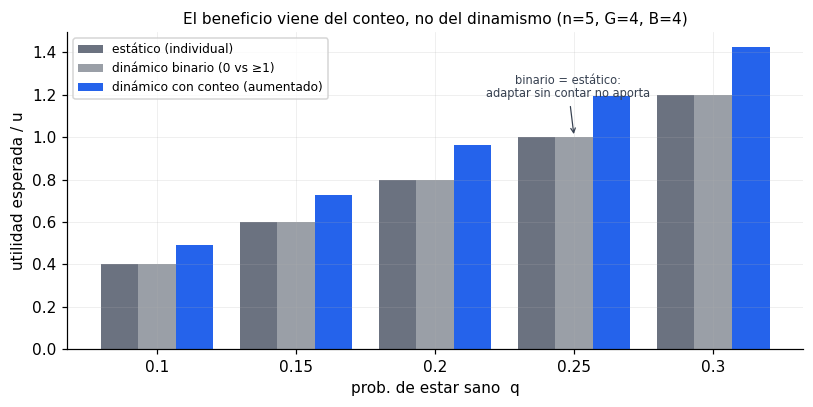

In [6]:
x = np.arange(len(qs_d)); w = 0.27
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(x - w, u_est, w, color=GRIS, label='estático (individual)')
ax.bar(x, u_bin, w, color=TINTA, alpha=0.5, label='dinámico binario (0 vs ≥1)')
ax.bar(x + w, u_cont, w, color=AZUL, label='dinámico con conteo (aumentado)')
ax.set_xticks(x); ax.set_xticklabels([str(q) for q in qs_d])
ax.set_xlabel('prob. de estar sano  q'); ax.set_ylabel('utilidad esperada / u')
ax.set_title('El beneficio viene del conteo, no del dinamismo (n=5, G=4, B=4)',
             fontsize=10)
ax.legend(fontsize=8, loc='upper left')
ax.annotate('binario = estático:\nadaptar sin contar no aporta',
            (x[3], u_bin[3]), textcoords='offset points', xytext=(-4, 26),
            fontsize=7.5, color=TINTA, ha='center',
            arrowprops=dict(arrowstyle='->', color=TINTA, lw=0.8))
fig.tight_layout(); plt.show()

**Lectura.** Las dos primeras barras coinciden en cada prevalencia: con
pruebas binarias, ser dinámico no compra nada sobre el estático (cada individual
es i.i.d.). Solo el conteo despega, y su ventaja crece con $q$. La separación no
es premio por ser dinámico, es **premio por contar**.

**Para discutir.** ¿Por qué no reportar esta descomposición (estático /
dinámico-binario / dinámico-conteo) como tabla de atribución? Cerraría de
antemano la objeción de "movieron dos variables a la vez".

## 2. Los regímenes tratables y un algoritmo eficiente

El cómputo del marginal posterior exacto es #P-difícil en general, pero se vuelve
tratable cuando el traslape es simple. Dos familias, verificadas contra fuerza
bruta y escaladas a tamaños imposibles de enumerar.

**Laminar: cajas dentro de cajas.** Imagínense pools anidados: si la caja
grande A reporta 5 infectados y su sub-caja B reporta 2, la capa de en medio
tiene exactamente 5-2=3. Los conteos se restan — todo esto es un ejercicio de
contar — y cada capa queda con conteo fijo: subproblemas "exactamente k de m",
exactos en O(m·k) sin enumerar 2^m.

In [7]:
from augmented.core import mask_from_indices
from augmented.bayesian import bayesian_update_by_counting
import time

def marginales_k_de_m(ps, k):
    '''P(Z_i=1 | exactamente k infectados entre estas m personas), exacto en
    O(m*k) via polinomios simetricos elementales (forward-backward) sobre las
    ODDS r_i = p_i/q_i. Trabajar en odds cancela el factor comun prod(q) y
    evita el underflow que mataria los pesos crudos con m grande
    (0.5^2000 ~ 1e-602 no cabe en un float; las esym de odds con k chico si).
    Formula: P(Z_i=1 | k de m) = r_i * e_{k-1}(r_(-i)) / e_k(r).'''
    m = len(ps)
    odds = [pi / (1.0 - pi) for pi in ps]
    F = [[1.0]]                      # F[i][j] = e_j(odds de los primeros i)
    for i in range(m):
        prev = F[-1]
        cur = [0.0] * (min(i + 1, k) + 1)
        for j, v in enumerate(prev):
            if j <= k:     cur[j] += v
            if j + 1 <= k: cur[j + 1] += v * odds[i]
        F.append(cur)
    Bk = [None] * (m + 1)            # Bk[i][j] = e_j(odds de i..m-1)
    Bk[m] = [1.0]
    for i in range(m - 1, -1, -1):
        nxt = Bk[i + 1]
        cur = [0.0] * (min(m - i, k) + 1)
        for j, v in enumerate(nxt):
            if j <= k:     cur[j] += v
            if j + 1 <= k: cur[j + 1] += v * odds[i]
        Bk[i] = cur
    Z = F[m][k]                      # e_k(todas las odds)
    marg = []
    for i in range(m):
        acc = 0.0
        for j, v in enumerate(F[i]):
            jj = k - 1 - j
            if 0 <= jj < len(Bk[i + 1]):
                acc += v * Bk[i + 1][jj]
        marg.append(odds[i] * acc / Z)
    return marg

# --- laminar en chiquito: n=12, A={0..11} r=5, B={0..5} r=2, C={0..2} r=1 ---
import random as _r
rng = _r.Random(3)
n = 12
p = [rng.uniform(0.2, 0.8) for _ in range(n)]
history = ((mask_from_indices(range(12)), 5),
           (mask_from_indices(range(6)), 2),
           (mask_from_indices(range(3)), 1))

# los conteos anidados se restan: capas C, B\C, A\B con conteos 1, 2-1=1, 5-2=3
capas = [(list(range(0, 3)), 1), (list(range(3, 6)), 1), (list(range(6, 12)), 3)]
t0 = time.perf_counter()
marg_dp = [0.0] * n
for inds, k in capas:
    for i, v in zip(inds, marginales_k_de_m([p[i] for i in inds], k)):
        marg_dp[i] = v
t_dp = time.perf_counter() - t0

t0 = time.perf_counter()
marg_bf = bayesian_update_by_counting(p, history, n)   # fuerza bruta 2^12
t_bf = time.perf_counter() - t0

err = max(abs(a - b) for a, b in zip(marg_dp, marg_bf))
assert err < 1e-9, f'laminar DP no coincide con fuerza bruta: {err}'
print(f'laminar n=12: max|DP - fuerza bruta| = {err:.1e}  '
      f'(DP {t_dp*1e3:.2f} ms, fuerza bruta {t_bf*1e3:.0f} ms)')
print('marginales (primeras 6):', [round(x, 4) for x in marg_dp[:6]])

laminar n=12: max|DP - fuerza bruta| = 2.2e-16  (DP 0.07 ms, fuerza bruta 0 ms)
marginales (primeras 6): [0.2207, 0.4705, 0.3089, 0.4349, 0.4587, 0.1065]


In [8]:
# --- el mismo régimen laminar a n = 6,000: la fuerza bruta necesitaría 2^6000 ---
n_big = 6000
rng = _r.Random(4)
p_big = [rng.uniform(0.2, 0.8) for _ in range(n_big)]
capas_big = [(list(range(0, 2000)), 3),        # capa interna: 3 infectados entre 2,000
             (list(range(2000, 4000)), 2),
             (list(range(4000, 6000)), 1)]
t0 = time.perf_counter()
marg_big = {}
for inds, k in capas_big:
    for i, v in zip(inds, marginales_k_de_m([p_big[i] for i in inds], k)):
        marg_big[i] = v
t_big = time.perf_counter() - t0
chk = sum(marg_big[i] for i in range(2000))
print(f'laminar n=6,000: marginales exactas en {t_big*1e3:.0f} ms '
      f'(la enumeración sería 2^6000 ~ 10^1806)')
print(f'consistencia: la capa interna suma E[infectados] = {chk:.6f} (debe ser 3)')

laminar n=6,000: marginales exactas en 6 ms (la enumeración sería 2^6000 ~ 10^1806)
consistencia: la capa interna suma E[infectados] = 3.000000 (debe ser 3)


**Cadena de pools (treewidth acotado).** Pools que comparten *una* persona
con el siguiente: $\{0,1,2\},\{2,3,4\},\dots$ Basta recordar el bit compartido;
un barrido forward–backward (junction tree mínimo) da el posterior en costo
lineal, no $2^n$.

In [9]:
def cadena_marginales(p, rs):
    '''Marginales exactas para pools en cadena {0,1,2},{2,3,4},... con conteos
    rs. Forward-backward sobre el bit de la persona compartida.'''
    m = len(rs)                       # pools; personas: 0..2m
    w = lambda i, z: p[i] if z else 1 - p[i]

    def T(i, s_prev, s):              # peso de transición del pool i>=1
        mid = 2 * i + 1
        acc = 0.0
        for zm in (0, 1):
            if s_prev + zm + s == rs[i]:
                acc += w(mid, zm)
        return acc * w(2 * i + 2, s)

    fwd = [[0.0, 0.0] for _ in range(m)]
    for z0 in (0, 1):                 # pool 0: personas 0,1 y frontera 2
        for z1 in (0, 1):
            for s in (0, 1):
                if z0 + z1 + s == rs[0]:
                    fwd[0][s] += w(0, z0) * w(1, z1) * w(2, s)
    for i in range(1, m):
        for s in (0, 1):
            fwd[i][s] = sum(fwd[i - 1][sp] * T(i, sp, s) for sp in (0, 1))

    bwd = [[1.0, 1.0] for _ in range(m)]
    for i in range(m - 1, 0, -1):
        for sp in (0, 1):
            bwd[i - 1][sp] = sum(T(i, sp, s) * bwd[i][s] for s in (0, 1))
    Z = sum(fwd[m - 1])

    marg = [0.0] * (2 * m + 1)
    for i in range(m):                # fronteras: personas 2i+2
        marg[2 * i + 2] = fwd[i][1] * bwd[i][1] / Z
    for i in range(1, m):             # medios: personas 2i+1
        acc = 0.0
        for sp in (0, 1):
            for s in (0, 1):
                if sp + 1 + s == rs[i]:
                    acc += fwd[i - 1][sp] * p[2 * i + 1] * w(2 * i + 2, s) * bwd[i][s]
        marg[2 * i + 1] = acc / Z
    for persona in (0, 1):            # personas 0 y 1 del pool 0
        acc = 0.0
        otra = 1 - persona
        for zo in (0, 1):
            for s in (0, 1):
                if 1 + zo + s == rs[0]:
                    acc += w(persona, 1) * w(otra, zo) * w(2, s) * bwd[0][s]
        marg[persona] = acc / Z
    return marg

# --- verificación contra fuerza bruta: 6 pools, n=13 ---
m, n = 6, 13
rng = _r.Random(5)
p = [rng.uniform(0.2, 0.8) for _ in range(n)]
z_real = [1 if rng.random() < p[i] else 0 for i in range(n)]
pools = [list(range(2 * i, 2 * i + 3)) for i in range(m)]
rs = [sum(z_real[j] for j in pool) for pool in pools]
history = tuple((mask_from_indices(pool), r) for pool, r in zip(pools, rs))

marg_dp = cadena_marginales(p, rs)
marg_bf = bayesian_update_by_counting(p, history, n)
err = max(abs(a - b) for a, b in zip(marg_dp, marg_bf))
assert err < 1e-9, f'cadena DP no coincide: {err}'
print(f'cadena de {m} pools (n={n}): max|DP - fuerza bruta| = {err:.1e}')

# --- y a escala: 200 pools solapados, n=401 ---
m2 = 200; n2 = 2 * m2 + 1
rng = _r.Random(6)
p2 = [rng.uniform(0.2, 0.8) for _ in range(n2)]
z2 = [1 if rng.random() < p2[i] else 0 for i in range(n2)]
rs2 = [z2[2*i] + z2[2*i+1] + z2[2*i+2] for i in range(m2)]
t0 = time.perf_counter()
marg2 = cadena_marginales(p2, rs2)
t2 = time.perf_counter() - t0
print(f'cadena de {m2} pools solapados (n={n2}): marginales exactas en '
      f'{t2*1e3:.1f} ms (la enumeración sería 2^{n2})')

cadena de 6 pools (n=13): max|DP - fuerza bruta| = 1.1e-16
cadena de 200 pools solapados (n=401): marginales exactas en 0.4 ms (la enumeración sería 2^401)


### El costo, en una imagen

El DP tratable hace un barrido lineal; la fuerza bruta recorre $2^n$ perfiles.
En la misma escala de tiempo, uno se queda en el piso y el otro atraviesa el
techo.

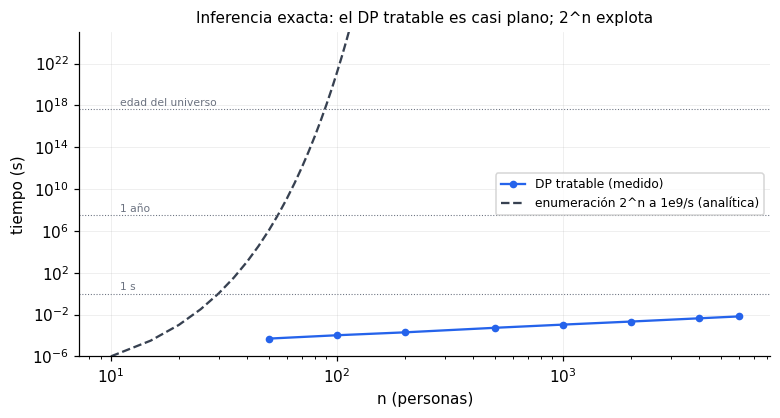

DP laminar a n=6,000: 7 ms.
la enumeración 2^n rebasa la edad del universo ya en n≈90.


In [10]:
# el DP tratable medido a varios n, contra la enumeración 2^n analítica
ns_dp = [50, 100, 200, 500, 1000, 2000, 4000, 6000]
t_dp = []
for nn in ns_dp:
    rng_s = _r.Random(nn)
    ps = [rng_s.uniform(0.2, 0.8) for _ in range(nn)]
    t0 = time.perf_counter(); marginales_k_de_m(ps, 3)
    t_dp.append(time.perf_counter() - t0)

RATE = 1e9                                   # perfiles/s: cota MUY optimista
ns_bf = list(range(10, 116, 5))
t_bf = [2.0 ** nn / RATE for nn in ns_bf]

fig, ax = plt.subplots(figsize=(7.2, 3.9))
ax.plot(ns_dp, t_dp, marker='o', ms=4, color=AZUL, label='DP tratable (medido)')
ax.plot(ns_bf, t_bf, ls='--', color=TINTA, label='enumeración 2^n a 1e9/s (analítica)')
for yv, tx in [(1.0, '1 s'), (3.15e7, '1 año'), (4.35e17, 'edad del universo')]:
    ax.axhline(yv, color=GRIS, lw=0.7, ls=':')
    ax.text(11, yv * 2.2, tx, fontsize=7, color=GRIS)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('n (personas)'); ax.set_ylabel('tiempo (s)')
ax.set_ylim(1e-6, 1e25)
ax.set_title('Inferencia exacta: el DP tratable es casi plano; 2^n explota',
             fontsize=10)
ax.legend(fontsize=8, loc='center right')
fig.tight_layout(); plt.show()
n_univ = next(nn for nn in ns_bf if 2.0 ** nn / RATE > 4.35e17)
print(f'DP laminar a n=6,000: {t_dp[-1]*1e3:.0f} ms.')
print(f'la enumeración 2^n rebasa la edad del universo ya en n≈{n_univ}.')

**Lectura.** El DP cruza más de dos órdenes de magnitud de $n$ (50→6,000)
sin salir de los milisegundos; la fuerza bruta rebasa la edad del universo antes
de n=90. No es "más rápido": es $O(m\,k)$ —lineal con $k$ fijo— donde el ingenuo
enfrenta $2^n$.

**Dónde encaja.** `bayesian.py` ya explota el primer peldaño (componentes
disjuntas); laminar y cadena son los siguientes. El frente del paper es meter
esta inferencia en el loop de decisión y medirla. El paper mandable es la terna:
separación + algoritmo eficiente en regímenes tratables + evidencia empírica.

**Para discutir.** ¿Vale la pena medir el treewidth efectivo de las
historias que el greedy genera —para saber en qué fracción de los pasos la
inferencia exacta es de verdad barata?

## 3. El modelo realista de pruebas: ¿sobrevive la separación al ruido?

El conteo real llega con ruido. De cuatro modelos posibles (ver
`paper/modelo_realista_pruebas.md`), aquí un canal de juguete: el conteo
verdadero r se observa como r + N(0, σ²) —ruido aditivo, independiente, sin
truncar—. No es aún un modelo de qPCR (Ct y carga viral no son un conteo lineal);
es el mínimo que hace ejecutable la pregunta del ruido.

**Intuición.** Hagan de cuenta que el binary search nunca lee el conteo
fino: solo pregunta un bit por paso, ¿este bloque está saturado o no? Y esa
discriminación es fácil — distinguir un bloque con un sano (conteo g-1) de uno
saturado (conteo g) es distinguir *una persona* del ruido, sin importar el
tamaño del bloque. Ojalá entonces aguante ruido; abajo medimos cuánto.

**Afirmación.** Con umbral a la mitad, el error peor-caso de una decisión
adyacente es $\varepsilon(\sigma)=\Phi(-1/(2\sigma))$, y la separación sobrevive
hasta un σ\* que mide la simulación. El estático se compara en su valor sin
ruido ($B\,q$), como referencia ideal. El ruido cobra un segundo precio: el
*falso-limpio*, certificar sano a un infectado.

In [11]:
from statistics import NormalDist
Phi = NormalDist().cdf

def eps_por_paso(sigma):
    '''Error peor-caso de una decisión saturado/no: umbral a media persona,
    gap de uno, ruido sigma. Independiente del tamaño del bloque.'''
    return 0.0 if sigma <= 0 else Phi(-0.5 / sigma)

def _busca_ruidosa(grupo, sigma, rng):
    '''Devuelve (indice_certificado_o_None, pruebas_usadas). La 1a prueba lee el
    conteo del grupo (¿saturado?); si no lo está, hace binary search de conteo.'''
    n = len(grupo)
    if sum(grupo) + rng.gauss(0, sigma) > n - 0.5:
        return None, 1                        # 1 prueba: el grupo se leyó saturado
    block = list(range(n)); usadas = 1
    while len(block) > 1:
        half = len(block) // 2; L = block[:half]; usadas += 1
        if sum(grupo[i] for i in L) + rng.gauss(0, sigma) < len(L) - 0.5:
            block = L
        else:
            block = block[half:]
    return block[0], usadas

def dinamico_ruidoso_mc(B, G, q, sigma, sims=20000, seed=0):
    '''Utilidad/u y falso-limpio por Monte Carlo, con presupuesto honesto: lee
    grupos frescos uno a uno y en el PRIMERO que lee como no-saturado entra,
    certifica a quien encuentra y SE DETIENE — sin mirar la verdad latente para
    decidir si sigue. Utilidad = P(el certificado esté sano de verdad).'''
    logG = round(math.log2(G)); k = B - logG
    if k < 1:
        return None, None
    rng = random.Random(seed)
    exitos = certificados = falsos = 0
    for _ in range(sims):
        tests = 0
        for _g in range(k):
            grupo = [0 if rng.random() < q else 1 for _ in range(G)]  # 0=sano
            x, usadas = _busca_ruidosa(grupo, sigma, rng)
            tests += usadas
            if x is None:
                continue                      # leído saturado: siguiente grupo fresco
            assert tests <= B, f'presupuesto excedido: {tests} > {B}'
            certificados += 1
            if grupo[x] == 1:
                falsos += 1                   # falso-limpio: se mide, no se actúa sobre ello
            else:
                exitos += 1
            break                             # certifica y se detiene, acierte o no
    return exitos / sims, (falsos / certificados if certificados else 0.0)

import random
q, G, B = 0.1, 16, 6
logG = round(math.log2(G)); k = B - logG
sin_ruido = util_dinamico(B, G, q)[0]
est = util_estatico(B, q)

# autoverificación: (a) sin ruido recupera la §1; (b) la cota conservadora
# (acertar las k+log2G decisiones del camino) nunca excede la verdad simulada.
mc0, _ = dinamico_ruidoso_mc(B, G, q, 0.0, sims=20000, seed=1)
assert abs(mc0 - sin_ruido) < 0.01, f'sigma=0 no recupera la §1: {mc0} vs {sin_ruido}'
for s in (0.2, 0.3, 0.5):
    mc, _ = dinamico_ruidoso_mc(B, G, q, s, sims=20000, seed=1)
    cota = sin_ruido * (1 - eps_por_paso(s)) ** (k + logG)
    assert cota <= mc + 0.02, f'la cota conservadora excede la verdad en sigma={s}'
print('autoverificación OK: sigma=0 recupera la §1; cota conservadora <= verdad MC')
print(f'estático (sin ruido) = {est:.3f}   din. aumentado sin ruido = {sin_ruido:.3f}')
for s in (0.0, 0.2, 0.3, 0.5, 0.8):
    mc, falso = dinamico_ruidoso_mc(B, G, q, s, sims=20000, seed=1)
    print(f'  sigma={s}: aumentado MC={mc:.3f}  falso-limpio={falso:.3f}  '
          f'eps/paso={eps_por_paso(s):.3f}')

autoverificación OK: sigma=0 recupera la §1; cota conservadora <= verdad MC
estático (sin ruido) = 0.600   din. aumentado sin ruido = 0.966
  sigma=0.0: aumentado MC=0.968  falso-limpio=0.000  eps/paso=0.000
  sigma=0.2: aumentado MC=0.948  falso-limpio=0.019  eps/paso=0.006
  sigma=0.3: aumentado MC=0.825  falso-limpio=0.146  eps/paso=0.048


  sigma=0.5: aumentado MC=0.559  falso-limpio=0.417  eps/paso=0.159
  sigma=0.8: aumentado MC=0.376  falso-limpio=0.603  eps/paso=0.266


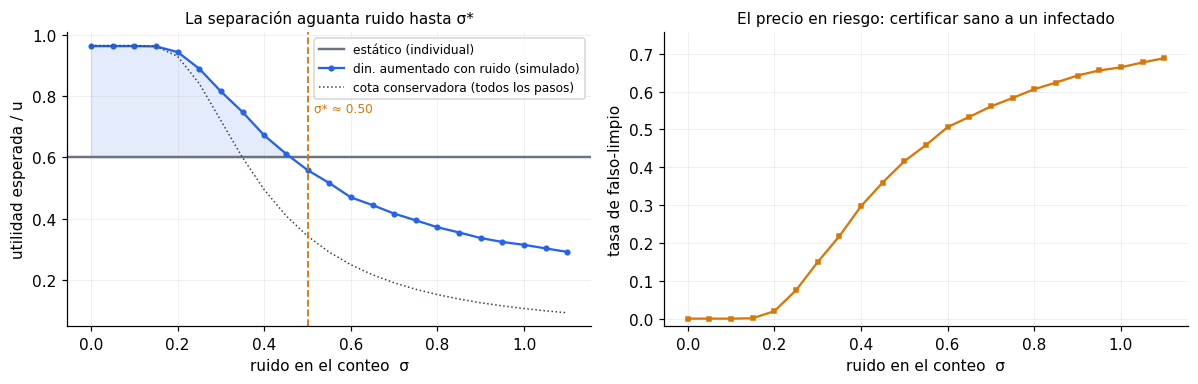

umbral de utilidad: σ* ≈ 0.50 (≈ media persona de ruido)


In [12]:
# figura: la separación contra el ruido (izq) y el precio en riesgo (der)
sigmas = np.linspace(0.0, 1.1, 23)
util = [dinamico_ruidoso_mc(B, G, q, float(s), sims=12000, seed=2)[0] for s in sigmas]
falso = [dinamico_ruidoso_mc(B, G, q, float(s), sims=12000, seed=2)[1] for s in sigmas]
cota = [sin_ruido * (1 - eps_por_paso(float(s))) ** (k + logG) for s in sigmas]
# umbral sigma*: donde la utilidad dinámica cruza el estático
sig_star = next((float(s) for s, m in zip(sigmas, util) if m < est), None)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.axhline(est, color=GRIS, lw=1.6, label='estático (individual)')
ax1.plot(sigmas, util, marker='o', ms=3, color=AZUL, label='din. aumentado con ruido (simulado)')
ax1.plot(sigmas, cota, ls=':', color=TINTA, lw=1, label='cota conservadora (todos los pasos)')
ax1.fill_between(sigmas, est, util, where=[u > est for u in util], color=AZUL, alpha=0.12)
if sig_star is not None:
    ax1.axvline(sig_star, color=AMBAR, ls='--', lw=1.2)
    ax1.annotate(f'σ* ≈ {sig_star:.2f}', (sig_star, est), textcoords='offset points',
                 xytext=(4, 30), fontsize=8, color=AMBAR)
ax1.set_xlabel('ruido en el conteo  σ'); ax1.set_ylabel('utilidad esperada / u')
ax1.set_title('La separación aguanta ruido hasta σ*', fontsize=10)
ax1.legend(fontsize=8, loc='upper right')

ax2.plot(sigmas, falso, marker='s', ms=3, color=AMBAR)
ax2.set_xlabel('ruido en el conteo  σ')
ax2.set_ylabel('tasa de falso-limpio')
ax2.set_title('El precio en riesgo: certificar sano a un infectado', fontsize=10)
ax2.set_ylim(-0.02, max(0.05, max(falso) * 1.1))
fig.tight_layout(); plt.show()
print(f'umbral de utilidad: σ* ≈ {sig_star:.2f} (≈ media persona de ruido)')

**Lectura.** La ventaja aguanta ruido hasta σ\* ≈ 0.5 —cerca de media
persona de ruido en el conteo—. La cota conservadora (acertar las k+log₂G
decisiones del camino) queda por debajo de la utilidad real, señal de que los
errores a veces se recuperan. El segundo precio pesa más: el falso-limpio crece
rápido —a σ=0.3 ya certifica a un infectado ~15% de las veces—, y para tamizaje
ese es el error peligroso.

**Para discutir.** ¿El objetivo bajo ruido es la utilidad media o la
utilidad *segura* (con el falso-limpio acotado)? ¿Y la re-medición (SPRT) empuja
σ\* arriba y el falso-limpio abajo a la vez, o hay un trade-off duro?

## 4. De qué está hecho el hueco del greedy: miopía e independencia

**Intuición.** El greedy comete dos pecados separables: es **miope** (elige por
la recompensa de este paso) y **puntúa con una aproximación** — estima P(pool
limpio) como el producto de marginales ∏(1−p̃ᵢ), que es falso en cuanto las
pruebas correlacionan a la gente. Para repartir la culpa usamos el mismo truco
de la §1.1, un peldaño intermedio: el greedy con **scoring exacto** (sigue
miope, pero puntúa con la P(r=0|H) conjunta verdadera).

**Afirmación.** hueco = OPT − greedy se parte en dos: **miopía** =
OPT − greedy exacto (la parte que ningún scoring puede curar) e
**independencia** = greedy exacto − greedy (la parte que el scoring exacto, ya
implementado, cierra). La miopía domina — alrededor de tres cuartos en el
régimen de referencia.

In [13]:
from augmented.greedy import greedy_myopic_expected_utility as greedy_eu
from augmented.independence_gap import exact_greedy_myopic_expected_utility as exact_eu

# receta del documento de referencia: p ~ U(0,1), u ∈ {1,2,3}, B=G=3
res = {}
for n_g, seeds in ((5, 15), (6, 12)):
    tm = ti = to = 0.0
    for seed in range(seeds):
        rng = _r.Random(1000 + seed)
        p = [rng.uniform(0.0, 1.0) for _ in range(n_g)]
        u = [float(rng.choice([1, 2, 3])) for _ in range(n_g)]
        g = greedy_eu(p, u, 3, 3)
        e = exact_eu(p, u, 3, 3)
        o = solve_optimal_dapts(p, u, 3, 3)[0]
        # autoverificación: ambas políticas son factibles => no superan al óptimo
        assert g <= o + 1e-9 and e <= o + 1e-9
        tm += o - e; ti += e - g; to += o - g
    assert tm > ti, f'la miopía no domina en n={n_g}'
    res[n_g] = (tm / to, ti / to)
    print(f'n={n_g} ({seeds} instancias): miopía {tm/to:.0%} del hueco, '
          f'independencia {ti/to:.0%}')

n=5 (15 instancias): miopía 64% del hueco, independencia 36%


n=6 (12 instancias): miopía 82% del hueco, independencia 18%


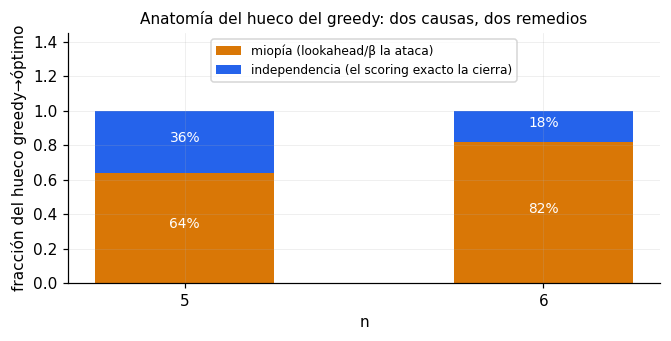

In [14]:
ns = list(res)
mi = [res[n][0] for n in ns]; ind = [res[n][1] for n in ns]
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.bar([str(n) for n in ns], mi, 0.5, color=AMBAR, label='miopía (lookahead/β la ataca)')
ax.bar([str(n) for n in ns], ind, 0.5, bottom=mi, color=AZUL,
       label='independencia (el scoring exacto la cierra)')
for i, n in enumerate(ns):
    ax.text(i, mi[i] / 2, f'{mi[i]:.0%}', ha='center', fontsize=9, color='white')
    ax.text(i, mi[i] + ind[i] / 2, f'{ind[i]:.0%}', ha='center', fontsize=9, color='white')
ax.set_xlabel('n'); ax.set_ylabel('fracción del hueco greedy→óptimo')
ax.set_ylim(0, 1.45)
ax.set_title('Anatomía del hueco del greedy: dos causas, dos remedios', fontsize=10)
ax.legend(fontsize=8, loc='upper center', ncol=1)
fig.tight_layout(); plt.show()

**Lectura.** La palanca grande es la miopía: la tendrías aun con scoring
perfecto, y solo el lookahead (o su proxy β, §5) la ataca. La independencia es
la palanca chica y barata — el scoring exacto ya existe (counting a n chico,
*estimado* por Gibbs a escala). Las proporciones bailan bastante con el régimen y
con tan pocas instancias; lo robusto es el orden (primero miopía), no los números.

**Para discutir.** Con estas pocas instancias las proporciones no son
estables (aquí 36% y 18%). A escala (n=20–50, donde solo Gibbs *estima* el
scoring), ¿vale medir con muchas semillas para ver si la independencia se vuelve
un tercio —y justifica pagar el Gibbs— o el lookahead sigue siendo el único gasto
que rinde?

## 5. El parámetro β: un lookahead barato

**Intuición.** El greedy miope maximiza P(r=0)·Σu: limpiar ahora. El beta-greedy
le suma un premiecito de información, β·info-gain, que a veces lo empuja a probar
un pool que limpia menos hoy pero informa mejor para el paso siguiente. Es un
proxy barato del lookahead — apunta a los tres cuartos de miopía de la §4.

**Afirmación.** En la instancia del notebook de árboles, subir β mueve el
pool de apertura hacia el que elige el óptimo y recupera ~85% del hueco. Pero es
un hump: demasiado β cae por debajo del greedy plano.

In [15]:
import random
from augmented.solver import solve_optimal_dapts
from augmented.state_reward_greedy import (greedy_myopic_beta_expected_utility as beu,
                                           _beta_best_pool)
from augmented.core import mask_str

# misma instancia que el notebook de árboles (n=4, B=2, G=2, semilla 185)
rb = random.Random(185); nb_, Bb, Gb = 4, 2, 2
pb = [rb.uniform(0.15, 0.7) for _ in range(nb_)]
ub = [rb.uniform(1.0, 4.0) for _ in range(nb_)]
opt_b = solve_optimal_dapts(pb, ub, Bb, Gb)[0]
greedy_plano = beu(pb, ub, Bb, Gb, 0.0)                 # beta=0 == greedy miope

betas = [round(0.25 * k, 2) for k in range(0, 33)]      # 0..8
eus = [beu(pb, ub, Bb, Gb, b, 'entropy') for b in betas]
best_eu = max(eus); best_beta = betas[eus.index(best_eu)]

# autoverificación: beta>0 mejora al greedy plano y ninguna beta supera al óptimo
assert best_eu > greedy_plano + 1e-6, 'ningún beta ayuda en esta instancia'
assert best_eu <= opt_b + 1e-9, 'beta-greedy superó al óptimo (imposible)'
recuperado = (best_eu - greedy_plano) / (opt_b - greedy_plano)
print(f'óptimo={opt_b:.3f}  greedy plano (β=0)={greedy_plano:.3f}  '
      f'mejor β={best_beta} → EU={best_eu:.3f}')
print(f'β recupera {recuperado:.0%} del hueco greedy→óptimo')
for b in (0.0, 1.0, 3.0, 5.0):
    print(f'  β={b}: EU={beu(pb,ub,Bb,Gb,b,"entropy"):.3f}  '
          f'abre con {mask_str(_beta_best_pool(pb,ub,Gb,nb_,0,b,"entropy"), nb_)}')

óptimo=2.892  greedy plano (β=0)=2.679  mejor β=3.0 → EU=2.861
β recupera 85% del hueco greedy→óptimo
  β=0.0: EU=2.679  abre con {2}
  β=1.0: EU=2.810  abre con {2,3}
  β=3.0: EU=2.861  abre con {1,2}
  β=5.0: EU=2.665  abre con {1,2}


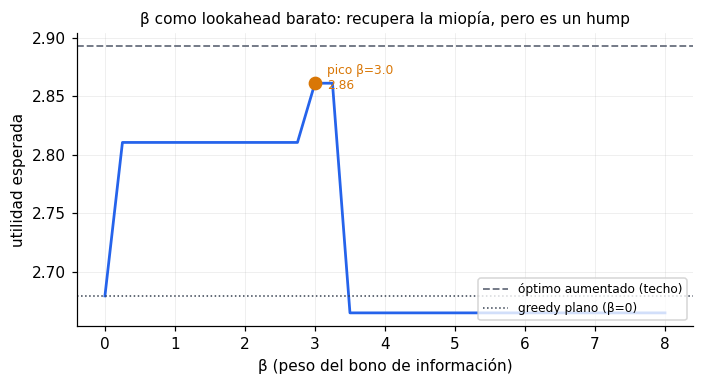

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(betas, eus, color=AZUL, lw=1.8)
ax.axhline(opt_b, color=GRIS, ls='--', lw=1.2, label='óptimo aumentado (techo)')
ax.axhline(greedy_plano, color=TINTA, ls=':', lw=1.0, label='greedy plano (β=0)')
ax.plot([best_beta], [best_eu], 'o', color=AMBAR, ms=8, zorder=3)
ax.annotate(f'pico β={best_beta}\n{best_eu:.2f}', (best_beta, best_eu),
            textcoords='offset points', xytext=(8, -4), fontsize=8, color=AMBAR)
ax.set_xlabel('β (peso del bono de información)')
ax.set_ylabel('utilidad esperada')
ax.set_title('β como lookahead barato: recupera la miopía, pero es un hump',
             fontsize=10)
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout(); plt.show()

**Lectura.** β hace de lookahead de un paso: el pool de apertura salta del
miope al informativo y la utilidad casi toca el techo. Pero es frágil: es un hump
(pasado el punto dulce elige peor) y a prevalencia alta se neutraliza ($P(r=0)$
colapsa). Proxy útil, pero hay que sintonizarlo.

**Para discutir.** β modifica la *política*; la V̂ del certificado modifica
la *cota*. ¿Es β un caso de la penalización, y su β óptima escala con el
horizonte, como la profundidad d(B) que buscamos para la V̂?